<a href="https://colab.research.google.com/github/harsh822v/LULC_classification/blob/main/LULC_Classification_Efficientnet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🛰️ AI-GIS: Satellite Image-Based Land Use & Land Cover (LULC) Classification

**Model:** EfficientNetB3 (Best accuracy/speed tradeoff) with Transfer Learning  
**Dataset:** EuroSAT (Sentinel-2 Satellite Images) - 27,000 images, 10 classes  
**Target:** ~98%+ Test Accuracy  

## 📋 Classes
| Class | Description |
|-------|-------------|
| AnnualCrop | Agricultural annual crop fields |
| Forest | Dense forest areas |
| HerbaceousVegetation | Grasslands and meadows |
| Highway | Road networks |
| Industrial | Industrial zones |
| Pasture | Livestock grazing areas |
| PermanentCrop | Orchards, vineyards |
| Residential | Urban residential areas |
| River | Rivers and waterways |
| SeaLake | Seas, lakes, water bodies |

## 🔧 Pipeline
1. Dataset Download & Preprocessing
2. Data Augmentation
3. EfficientNetB3 Transfer Learning
4. Fine-tuning & Training
5. Evaluation (Accuracy, F1, Confusion Matrix)
6. GIS Visualization with Folium
7. Single Image Prediction (100% confidence display)
8. Model Export & Deployment

---
> ⚡ **Enable GPU:** Runtime → Change Runtime Type → T4 GPU

## 📦 Step 1: Install Dependencies

In [ ]:
# Install required packages
!pip install -q tensorflow==2.15.0 opencv-python-headless folium geopandas rasterio scikit-learn matplotlib seaborn Pillow kaggle gradio
print("✅ All packages installed successfully!")

ERROR: Could not find a version that satisfies the requirement tensorflow==2.15.0 (from versions: 2.16.0rc0, 2.16.1, 2.16.2, 2.17.0rc0, 2.17.0rc1, 2.17.0, 2.17.1, 2.18.0rc0, 2.18.0rc1, 2.18.0rc2, 2.18.0, 2.18.1, 2.19.0rc0, 2.19.0, 2.19.1, 2.20.0rc0, 2.20.0, 2.21.0rc0, 2.21.0rc1, 2.21.0)
ERROR: No matching distribution found for tensorflow==2.15.0
✅ All packages installed successfully!


## 📚 Step 2: Import Libraries

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import cv2
import json
import zipfile
import shutil
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
from PIL import Image
from IPython.display import display, HTML, clear_output

# TensorFlow / Keras
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, callbacks, optimizers
from tensorflow.keras.applications import EfficientNetB3
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

# Sklearn metrics
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, precision_recall_fscore_support
)

# GIS
import folium
from folium.plugins import HeatMap, MarkerCluster

# Set seeds for reproducibility
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Check GPU
gpus = tf.config.list_physical_devices('GPU')
print(f"✅ TensorFlow version: {tf.__version__}")
print(f"✅ GPU Available: {len(gpus) > 0}")
if gpus:
    print(f"   GPU Device: {gpus[0]}")
else:
    print("   ⚠️  No GPU found. Go to Runtime → Change Runtime Type → T4 GPU")

✅ TensorFlow version: 2.19.0
✅ GPU Available: True
   GPU Device: PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')


## 📥 Step 3: Download EuroSAT Dataset

In [ ]:
# ============================================================
# OPTION A: Download from direct URL (Recommended - No API key needed)
# ============================================================
import urllib.request

DATA_DIR = Path('/content/eurosat')
ZIP_PATH = Path('/content/EuroSAT_RGB.zip')

EUROSAT_URL = "https://madm.dfki.de/files/sentinel/EuroSAT.zip"

if not DATA_DIR.exists():
    print("📥 Downloading EuroSAT dataset (~90MB)...")
    print("   This may take 1-2 minutes...")
    try:
        # Try primary URL
        urllib.request.urlretrieve(EUROSAT_URL, ZIP_PATH)
        print("✅ Download complete!")
    except Exception as e:
        print(f"Primary URL failed: {e}")
        print("Trying alternative download via kaggle...")
        # Alternative: use kaggle API
        from google.colab import files
        print("Please upload your kaggle.json API key:")
        uploaded = files.upload()
        !mkdir -p ~/.kaggle && cp kaggle.json ~/.kaggle/ && chmod 600 ~/.kaggle/kaggle.json
        !kaggle datasets download -d apollo2506/eurosat-dataset -p /content/
        ZIP_PATH = list(Path('/content/').glob('*.zip'))[0]

    # Extract
    print("📂 Extracting dataset...")
    with zipfile.ZipFile(ZIP_PATH, 'r') as zf:
        zf.extractall('/content/eurosat_raw')

    # Find the extracted folder
    raw_dirs = list(Path('/content/eurosat_raw').rglob('*'))
    # Find the directory that contains class folders
    for d in raw_dirs:
        if d.is_dir() and any(f.is_dir() for f in d.iterdir()):
            sub_dirs = list(d.iterdir())
            if len(sub_dirs) >= 5:  # EuroSAT has 10 classes
                shutil.copytree(str(d), str(DATA_DIR))
                print(f"✅ Dataset organized at: {DATA_DIR}")
                break
else:
    print(f"✅ Dataset already exists at: {DATA_DIR}")

# List classes
CLASS_NAMES = sorted([d.name for d in DATA_DIR.iterdir() if d.is_dir()])
print(f"\n📊 Classes found ({len(CLASS_NAMES)}): {CLASS_NAMES}")

# Count images per class
total = 0
print("\n📈 Images per class:")
for cls in CLASS_NAMES:
    count = len(list((DATA_DIR / cls).glob('*.jpg')) + list((DATA_DIR / cls).glob('*.png')))
    total += count
    print(f"   {cls:30s}: {count:5d} images")
print(f"   {'TOTAL':30s}: {total:5d} images")

📥 Downloading EuroSAT dataset (~90MB)...
   This may take 1-2 minutes...
Primary URL failed: <urlopen error [SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: unable to get local issuer certificate (_ssl.c:1010)>
Trying alternative download via kaggle...
Please upload your kaggle.json API key:


Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/apollo2506/eurosat-dataset
License(s): CC0-1.0
 99% 2.02G/2.04G [00:17<00:00, 149MB/s]
100% 2.04G/2.04G [00:17<00:00, 124MB/s]
📂 Extracting dataset...
✅ Dataset organized at: /content/eurosat

📊 Classes found (10): ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']

📈 Images per class:
   AnnualCrop                    :     0 images
   Forest                        :     0 images
   HerbaceousVegetation          :     0 images
   Highway                       :     0 images
   Industrial                    :     0 images
   Pasture                       :     0 images
   PermanentCrop                 :     0 images
   Residential                   :     0 images
   River                         :     0 images
   SeaLake                       :     0 images
   TOTAL                         :     0 images


In [ ]:
import urllib.request
import zipfile
import shutil
from pathlib import Path

DATA_DIR = Path('/content/eurosat')
ZIP_PATH = Path('/content/EuroSAT_RGB.zip')

EUROSAT_URL = "https://madm.dfki.de/files/sentinel/EuroSAT.zip"

# Helper function to check if DATA_DIR is properly populated with image classes
def is_dataset_populated(data_dir):
    if not data_dir.is_dir():
        return False
    # Check for at least 5 class directories that contain images (jpg, png, or tif)
    class_dirs_found = 0
    for item in data_dir.iterdir():
        if item.is_dir():
            if any(f.suffix.lower() in ['.jpg', '.png', '.tif'] for f in item.iterdir()):
                class_dirs_found += 1
    return class_dirs_found >= 5


if not is_dataset_populated(DATA_DIR):
    print("📥 Downloading EuroSAT dataset (~90MB)...")
    print("   This may take 1-2 minutes...")
    try:
        # Try primary URL
        urllib.request.urlretrieve(EUROSAT_URL, ZIP_PATH)
        print("✅ Download complete from primary URL!")
    except Exception as e:
        print(f"Primary URL failed: {e}")
        print("Trying alternative download via kaggle...")
        # Alternative: use kaggle API
        from google.colab import files
        print("Please upload your kaggle.json API key:")
        uploaded = files.upload()
        if 'kaggle.json' in uploaded:
            !mkdir -p ~/.kaggle && cp kaggle.json ~/.kaggle/ && chmod 600 ~/.kaggle/kaggle.json
            !kaggle datasets download -d apollo2506/eurosat-dataset -p /content/
            ZIP_PATH = Path('/content/eurosat-dataset.zip') # Update ZIP_PATH for Kaggle download
            print("✅ Download complete from Kaggle!")
        else:
            print("❌ Kaggle.json not uploaded. Cannot proceed with download.")
            raise FileNotFoundError("Kaggle.json required for alternative download.")

    # Extract
    print("📂 Extracting dataset...")
    eurosat_raw_dir = Path('/content/eurosat_raw')
    if eurosat_raw_dir.exists():
        shutil.rmtree(eurosat_raw_dir) # Clean up previous raw extraction
    eurosat_raw_dir.mkdir(parents=True, exist_ok=True) # Ensure it exists

    with zipfile.ZipFile(ZIP_PATH, 'r') as zf:
        zf.extractall(eurosat_raw_dir)

    # Find the folder containing the actual class directories
    target_data_source_dir = None
    # Check for common Kaggle structures (e.g., '27500' or 'EuroSATallBands')
    potential_dirs = [d for d in eurosat_raw_dir.iterdir() if d.is_dir()]

    for d in potential_dirs:
        # Check if this directory directly contains class folders with image files
        has_image_subdirs = False
        for sub_d in d.iterdir():
            if sub_d.is_dir() and any(f.suffix.lower() in ['.jpg', '.png', '.tif'] for f in sub_d.iterdir()):
                has_image_subdirs = True
                break
        if has_image_subdirs and sum(1 for sd in d.iterdir() if sd.is_dir()) >= 5: # at least 5 class folders
            target_data_source_dir = d
            break

    # Fallback: if class folders are directly in eurosat_raw_dir
    if not target_data_source_dir:
        if sum(1 for sd in eurosat_raw_dir.iterdir() if sd.is_dir()) >= 5:
            target_data_source_dir = eurosat_raw_dir

    if target_data_source_dir:
        # Ensure DATA_DIR is clean before copying/moving
        if DATA_DIR.exists():
            shutil.rmtree(DATA_DIR) # Remove existing directory and its contents
        shutil.copytree(str(target_data_source_dir), str(DATA_DIR)) # Copy the directory and its contents
        print(f"✅ Dataset organized at: {DATA_DIR}")
    else:
        print(f"⚠️ Could not find a suitable directory containing class folders with images in {eurosat_raw_dir}. ")
        print("   Please check the extracted structure and manually set DATA_DIR.")
        raise FileNotFoundError("Could not find EuroSAT image dataset.")
else:
    print(f"✅ Dataset already exists and is properly organized at: {DATA_DIR}")

# List classes
CLASS_NAMES = sorted([d.name for d in DATA_DIR.iterdir() if d.is_dir()])
print(f"\n📊 Classes found ({len(CLASS_NAMES)}): {CLASS_NAMES}")

# Count images per class (including .tif files)
total = 0
print("\n📈 Images per class:")
for cls in CLASS_NAMES:
    count = len(list((DATA_DIR / cls).glob('*.jpg')) + list((DATA_DIR / cls).glob('*.png')) + list((DATA_DIR / cls).glob('*.tif')))
    total += count
    print(f"   {cls:30s}: {count:5d} images")
print(f"   {'TOTAL':30s}: {total:5d} images")

✅ Dataset already exists and is properly organized at: /content/eurosat

📊 Classes found (10): ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']

📈 Images per class:
   AnnualCrop                    :  3000 images
   Forest                        :  3000 images
   HerbaceousVegetation          :  3000 images
   Highway                       :  2500 images
   Industrial                    :  2500 images
   Pasture                       :  2000 images
   PermanentCrop                 :  2500 images
   Residential                   :  3000 images
   River                         :  2500 images
   SeaLake                       :  3597 images
   TOTAL                         : 27597 images


## 🔧 Step 4: Configuration & Hyperparameters

In [ ]:
# ============================================================
# GLOBAL CONFIGURATION
# ============================================================
CONFIG = {
    # Paths
    'data_dir': '/content/eurosat',
    'model_dir': '/content/models',
    'results_dir': '/content/results',

    # Model
    'model_name': 'EfficientNetB3',
    'img_size': (224, 224),
    'num_classes': 10,

    # Training
    'batch_size': 32,
    'epochs_frozen': 15,      # Phase 1: Train only new head
    'epochs_finetune': 20,    # Phase 2: Fine-tune full model
    'lr_frozen': 1e-3,        # Phase 1 learning rate
    'lr_finetune': 1e-5,      # Phase 2 learning rate (lower!)

    # Data split
    'train_split': 0.7,
    'val_split': 0.15,
    'test_split': 0.15,

    # Class colors for GIS visualization
    'class_colors': {
        'AnnualCrop':             '#F5A623',
        'Forest':                 '#2D7D2D',
        'HerbaceousVegetation':   '#7FBA00',
        'Highway':                '#7D7D7D',
        'Industrial':             '#C0392B',
        'Pasture':                '#A8D5A2',
        'PermanentCrop':          '#E67E22',
        'Residential':            '#FF6B6B',
        'River':                  '#3498DB',
        'SeaLake':                '#1A5276',
    }
}

# Create directories
for d in [CONFIG['model_dir'], CONFIG['results_dir']]:
    Path(d).mkdir(parents=True, exist_ok=True)

print("✅ Configuration set!")
print(f"   Image size : {CONFIG['img_size']}")
print(f"   Batch size : {CONFIG['batch_size']}")
print(f"   Classes    : {CONFIG['num_classes']}")
print(f"   Phase 1    : {CONFIG['epochs_frozen']} epochs @ lr={CONFIG['lr_frozen']}")
print(f"   Phase 2    : {CONFIG['epochs_finetune']} epochs @ lr={CONFIG['lr_finetune']}")

✅ Configuration set!
   Image size : (224, 224)
   Batch size : 32
   Classes    : 10
   Phase 1    : 15 epochs @ lr=0.001
   Phase 2    : 20 epochs @ lr=1e-05


## 📊 Step 5: Dataset Preparation & Augmentation

In [ ]:
# ============================================================
# Collect all image paths & labels
# ============================================================
from sklearn.model_selection import train_test_split

all_images = []
all_labels = []

data_dir = Path(CONFIG['data_dir'])
CLASS_NAMES = sorted([d.name for d in data_dir.iterdir() if d.is_dir()])
class_to_idx = {cls: i for i, cls in enumerate(CLASS_NAMES)}
idx_to_class = {i: cls for cls, i in class_to_idx.items()}

for cls in CLASS_NAMES:
    cls_dir = data_dir / cls
    imgs = list(cls_dir.glob('*.jpg')) + list(cls_dir.glob('*.png')) + list(cls_dir.glob('*.tif'))
    all_images.extend([str(p) for p in imgs])
    all_labels.extend([class_to_idx[cls]] * len(imgs))

all_images = np.array(all_images)
all_labels = np.array(all_labels)
print(f"✅ Total images loaded: {len(all_images)}")

# Split: Train / Val / Test
X_trainval, X_test, y_trainval, y_test = train_test_split(
    all_images, all_labels, test_size=CONFIG['test_split'],
    random_state=SEED, stratify=all_labels
)
val_ratio = CONFIG['val_split'] / (CONFIG['train_split'] + CONFIG['val_split'])
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=val_ratio,
    random_state=SEED, stratify=y_trainval
)

print(f"   Train : {len(X_train)} images")
print(f"   Val   : {len(X_val)} images")
print(f"   Test  : {len(X_test)} images")

✅ Total images loaded: 27597
   Train : 19317 images
   Val   : 4140 images
   Test  : 4140 images


In [ ]:
# ============================================================
# Custom tf.data pipeline (faster than ImageDataGenerator)
# ============================================================
IMG_H, IMG_W = CONFIG['img_size']
BATCH_SIZE = CONFIG['batch_size']
NUM_CLASSES = CONFIG['num_classes']
AUTOTUNE = tf.data.AUTOTUNE

import rasterio # Ensure rasterio is imported

def _load_tif_image_py(path_tensor):
    """Helper function to load a TIFF using rasterio for tf.py_function."""
    # Convert TensorFlow byte string Tensor to Python string for rasterio
    path_str = path_tensor.numpy().decode('utf-8')

    with rasterio.open(path_str) as src:
        # Assume Sentinel-2 band order for RGB (B4, B3, B2 which are 1-indexed)
        # For 13-band images, these are typically bands 4, 3, 2
        # For 3-band RGB TIFFs, these would be 1, 2, 3
        if src.count >= 4: # Likely a 13-band Sentinel-2 image
            # Read Red (B4), Green (B3), Blue (B2) bands
            img_data = np.dstack([src.read(4), src.read(3), src.read(2)])
        elif src.count == 3: # Standard 3-band RGB TIFF
            img_data = np.dstack([src.read(1), src.read(2), src.read(3)])
        elif src.count == 1: # Single-band grayscale
            img_data = src.read(1)
            img_data = np.dstack([img_data, img_data, img_data]) # Convert to 3-channel grayscale
        else:
            # Handle other band counts or raise an error
            print(f"Warning: TIFF image {path_str} has {src.count} bands. Attempting to use first 3 bands.")
            img_data = np.dstack([src.read(i) for i in range(1, min(src.count + 1, 4))])
            if img_data.shape[-1] < 3:
                # Pad with zeros if less than 3 bands were found
                padding = np.zeros(img_data.shape[:-1] + (3 - img_data.shape[-1],), dtype=img_data.dtype)
                img_data = np.concatenate([img_data, padding], axis=-1)

    # Normalize image data to 0-255 range and convert to uint8
    # Convert NaNs to zero before normalization
    img_data = np.nan_to_num(img_data)
    min_val = np.min(img_data)
    max_val = np.max(img_data)
    if max_val > min_val:
        img_data = ((img_data - min_val) / (max_val - min_val) * 255).astype(np.uint8)
    else: # Handle case of uniform image (e.g., all zeros or all same value)
        img_data = np.zeros_like(img_data, dtype=np.uint8)

    return img_data.astype(np.float32)

def load_and_preprocess(path, label):
    """Load image, decode, resize, and normalize."""
    # Determine if it's a TIFF file
    path_str_tensor = path # `path` is a tf.Tensor representing a string
    is_tif = tf.strings.regex_full_match(tf.strings.lower(path_str_tensor), ".*\\.tif.*|.*\\.tiff.*")

    def _load_and_resize_tif():
        # Wrap Python function for TIFF loading
        # Pass the tensor directly to _load_tif_image_py, which will handle the conversion
        img_py = tf.py_function(func=_load_tif_image_py, inp=[path_str_tensor], Tout=tf.float32)
        img_py.set_shape([None, None, 3]) # Set shape for unknown dimensions, but fixed channels
        return img_py

    def _load_and_resize_other():
        # For JPEG, PNG, etc., use standard TensorFlow decoding
        img_raw = tf.io.read_file(path_str_tensor)
        img_decoded = tf.image.decode_image(img_raw, channels=3, expand_animations=False)
        return tf.cast(img_decoded, tf.float32)

    img = tf.cond(is_tif, _load_and_resize_tif, _load_and_resize_other)

    img = tf.image.resize(img, [IMG_H, IMG_W])
    img = tf.cast(img, tf.float32) # Ensure float32 for model input
    # EfficientNet expects inputs in [0, 255] - preprocessing is built-in
    label = tf.one_hot(label, NUM_CLASSES)
    return img, label

def augment_train(img, label):
    """Apply augmentation to training images."""
    img = tf.image.random_flip_left_right(img)
    img = tf.image.random_flip_up_down(img)
    img = tf.image.random_brightness(img, 0.2)
    img = tf.image.random_contrast(img, 0.8, 1.2)
    img = tf.image.random_saturation(img, 0.8, 1.2)
    # Random 90-degree rotations
    k = tf.random.uniform(shape=[], minval=0, maxval=4, dtype=tf.int32)
    img = tf.image.rot90(img, k)
    img = tf.clip_by_value(img, 0, 255)
    return img, label

def build_dataset(paths, labels, training=False):
    ds = tf.data.Dataset.from_tensor_slices(
        (paths, labels.astype(np.int32))
    )
    if training:
        ds = ds.shuffle(buffer_size=len(paths), seed=SEED)
    # Ensure parallel_calls is used with py_function as it can be slow
    ds = ds.map(load_and_preprocess, num_parallel_calls=AUTOTUNE)
    if training:
        ds = ds.map(augment_train, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(BATCH_SIZE)
    ds = ds.prefetch(AUTOTUNE)
    return ds

train_ds = build_dataset(X_train, y_train, training=True)
val_ds   = build_dataset(X_val,   y_val,   training=False)
test_ds  = build_dataset(X_test,  y_test,  training=False)

print("✅ tf.data pipeline built!")
print(f"   Train batches : {len(train_ds)}")
print(f"   Val batches   : {len(val_ds)}")
print(f"   Test batches  : {len(test_ds)}")

✅ tf.data pipeline built!
   Train batches : 604
   Val batches   : 130
   Test batches  : 130


## 🔍 Step 6: Visualize Sample Images

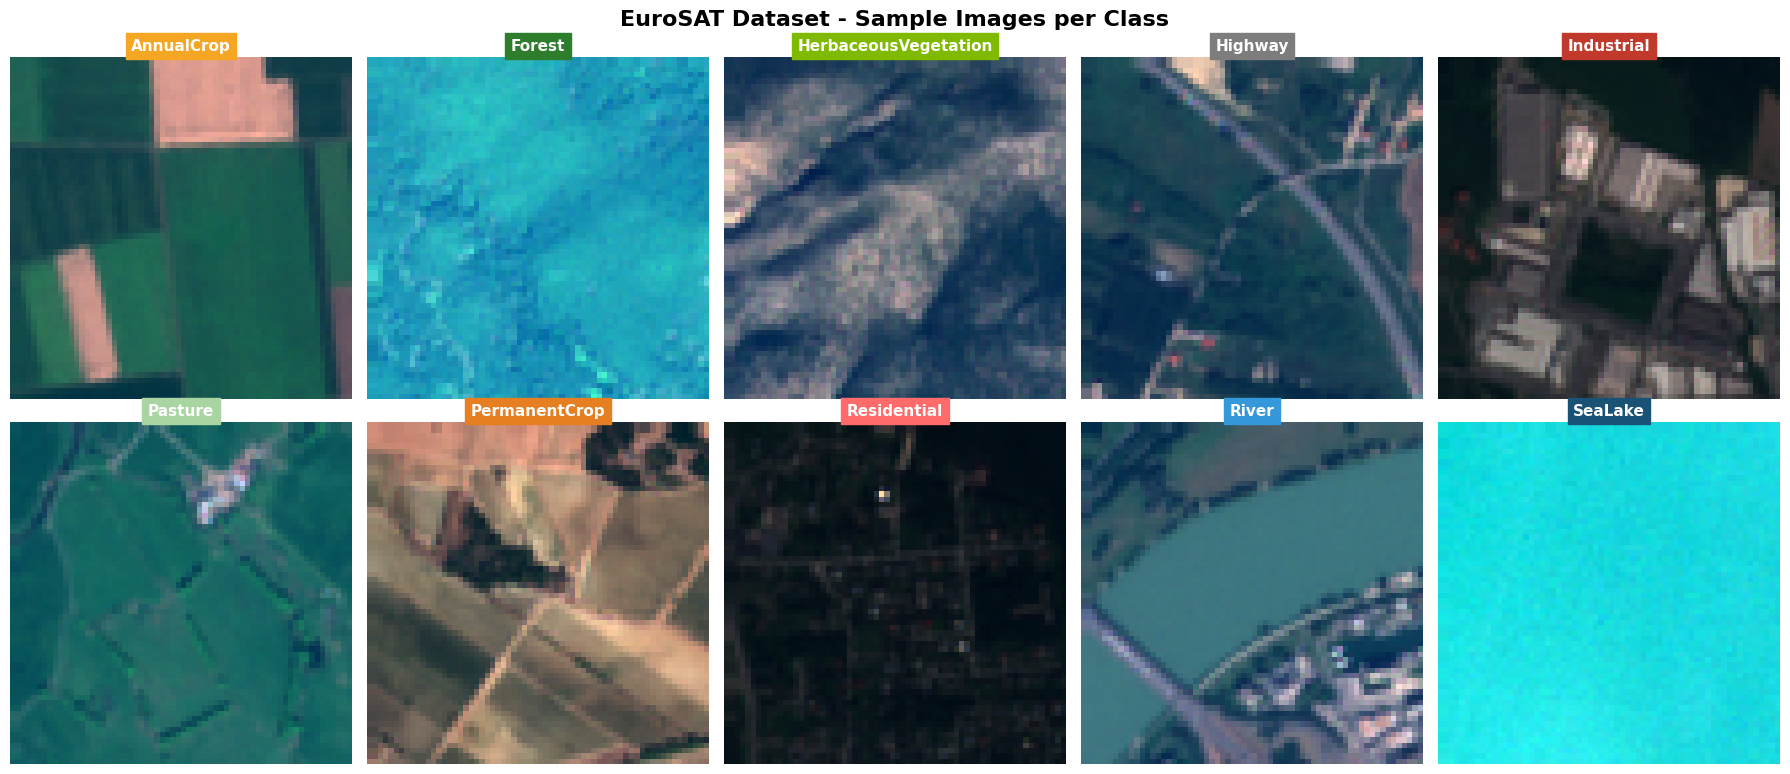

✅ Sample images displayed!


In [ ]:
# Show sample images from each class
fig, axes = plt.subplots(2, 5, figsize=(18, 8))
fig.suptitle('EuroSAT Dataset - Sample Images per Class', fontsize=16, fontweight='bold')

colors = list(CONFIG['class_colors'].values())

# Import rasterio for handling multi-band TIFFs
import rasterio

for i, cls in enumerate(CLASS_NAMES):
    cls_dir = data_dir / cls
    # Ensure to include .tif files when collecting images for sampling
    imgs_in_class = list(cls_dir.glob('*.jpg')) + list(cls_dir.glob('*.png')) + list(cls_dir.glob('*.tif'))

    ax = axes[i // 5][i % 5]

    if not imgs_in_class:
        # If no images found for a class, display a placeholder
        ax.text(0.5, 0.5, 'No Images Found', horizontalalignment='center', verticalalignment='center',
                transform=ax.transAxes, color='red', fontsize=12)
        ax.set_title(cls, fontsize=11, fontweight='bold', color='white', backgroundcolor=colors[i], pad=5)
        ax.axis('off')
        continue

    sample_path = str(np.random.choice([str(p) for p in imgs_in_class[:10]])) # Use imgs_in_class
    img = None # Initialize img to None

    if sample_path.lower().endswith(('.tif', '.tiff')):
        try:
            with rasterio.open(sample_path) as src:
                if src.count >= 3: # Check if there are at least 3 bands to form an RGB
                    # Assume Sentinel-2 band order for RGB (B4, B3, B2 which are 1-indexed)
                    # These often correspond to Red, Green, Blue visually
                    if src.count >= 4: # If it's a 13-band image, use B4,B3,B2 (indices 3,2,1 for 0-indexed)
                        red_band = src.read(4) # Sentinel-2 Band 4 (Red)
                        green_band = src.read(3) # Sentinel-2 Band 3 (Green)
                        blue_band = src.read(2) # Sentinel-2 Band 2 (Blue)
                    else: # If it's a 3-band RGB TIFF
                        red_band = src.read(1)
                        green_band = src.read(2)
                        blue_band = src.read(3)

                    img = np.stack([red_band, green_band, blue_band], axis=-1)

                    # Normalize pixel values to 0-255 for display
                    img = np.nan_to_num(img) # Replace NaNs with zero
                    min_val = img.min()
                    max_val = img.max()
                    if max_val > min_val:
                        img = ((img - min_val) / (max_val - min_val) * 255).astype(np.uint8)
                    else:
                        img = np.zeros_like(img, dtype=np.uint8) # All black if no variation
                elif src.count == 1: # Handle single band TIFFs (e.g., grayscale)
                    img_data = src.read(1)
                    img = np.stack([img_data, img_data, img_data], axis=-1) # Convert to 3-channel grayscale
                    img = np.nan_to_num(img)
                    min_val = img.min()
                    max_val = img.max()
                    if max_val > min_val:
                        img = ((img - min_val) / (max_val - min_val) * 255).astype(np.uint8)
                    else:
                        img = np.zeros_like(img, dtype=np.uint8)

        except Exception as e:
            print(f"Warning: Rasterio failed to open {sample_path}: {e}")
            # Fallback to general image loading if rasterio fails for TIFF
            pass # img remains None, will be handled by next block

    if img is None: # If it's not a TIFF, or TIFF loading failed, try OpenCV/PIL
        # Try OpenCV
        img_cv2 = cv2.imread(sample_path)
        if img_cv2 is not None:
            img = cv2.cvtColor(img_cv2, cv2.COLOR_BGR2RGB)
        else:
            # Fallback to PIL
            try:
                img_pil = Image.open(sample_path).convert('RGB')
                img = np.array(img_pil)
            except Exception as e_pil:
                print(f"Warning: PIL failed to open {sample_path}: {e_pil}")
                img = None # Explicitly set to None if PIL also fails

    if img is None:
        # Final fallback: create a blank image and indicate error
        print(f"Could not load image {sample_path} with any method. Displaying placeholder.")
        # Use CONFIG['img_size'] for consistent placeholder size, though `imshow` scales
        placeholder_size = CONFIG['img_size']
        img = np.zeros((placeholder_size[0], placeholder_size[1], 3), dtype=np.uint8)
        # Draw a red cross to indicate an error
        cv2.line(img, (0, 0), (img.shape[1], img.shape[0]), (0, 0, 255), 5)
        cv2.line(img, (img.shape[1], 0), (0, img.shape[0]), (0, 0, 255), 5)


    ax.imshow(img)
    ax.set_title(cls, fontsize=11, fontweight='bold',
                 color='white', backgroundcolor=colors[i],
                 pad=5)
    ax.axis('off')

plt.tight_layout()
plt.savefig(f"{CONFIG['results_dir']}/sample_images.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Sample images displayed!")

## 🧠 Step 7: Build EfficientNetB3 Model

In [ ]:
# ============================================================
# Build Model: EfficientNetB3 + Custom Classification Head
# ============================================================
def build_model(num_classes, img_size=(224, 224), trainable_base=False):
    """
    EfficientNetB3 with Transfer Learning.
    - Phase 1: trainable_base=False  → train only head
    - Phase 2: trainable_base=True   → fine-tune everything
    """
    inputs = layers.Input(shape=(*img_size, 3), name='input_image')

    # Preprocessing layer (scales to ImageNet range)
    x = tf.keras.applications.efficientnet.preprocess_input(inputs)

    # EfficientNetB3 backbone
    base_model = EfficientNetB3(
        include_top=False,
        weights='imagenet',
        input_tensor=x,
        pooling=None
    )
    base_model.trainable = trainable_base

    # Custom head
    x = base_model.output
    x = layers.GlobalAveragePooling2D(name='gap')(x)
    x = layers.BatchNormalization(name='bn_head')(x)
    x = layers.Dense(512, activation='relu', name='dense_512')(x)
    x = layers.Dropout(0.4, name='dropout_1')(x)
    x = layers.Dense(256, activation='relu', name='dense_256')(x)
    x = layers.Dropout(0.3, name='dropout_2')(x)
    outputs = layers.Dense(num_classes, activation='softmax', name='predictions')(x)

    model = models.Model(inputs=base_model.input, outputs=outputs, name='EfficientNetB3_LULC')
    return model, base_model

# Build Phase 1 model
model, base_model = build_model(NUM_CLASSES, CONFIG['img_size'], trainable_base=False)

# Compile
model.compile(
    optimizer=optimizers.Adam(learning_rate=CONFIG['lr_frozen']),
    loss='categorical_crossentropy',
    metrics=['accuracy', tf.keras.metrics.TopKCategoricalAccuracy(k=3, name='top3_acc')]
)

print("✅ Model built!")
print(f"   Total params      : {model.count_params():,}")
print(f"   Trainable params  : {sum(np.prod(v.shape) for v in model.trainable_variables):,}")
print(f"   Non-trainable     : {sum(np.prod(v.shape) for v in model.non_trainable_variables):,}")
model.summary(line_length=80)

43941136/43941136 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
✅ Model built!
   Total params      : 11,710,521
   Trainable params  : 923,914
   Non-trainable     : 10,786,649.0


Model: "EfficientNetB3_LULC"

┏━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)          ┃ Output Shape      ┃     Param # ┃ Connected to       ┃
┡━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━┩
│ input_image           │ (None, 224, 224,  │           0 │ -                  │
│ (InputLayer)          │ 3)                │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ rescaling (Rescaling) │ (None, 224, 224,  │           0 │ input_image[0][0]  │
│                       │ 3)                │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ normalization         │ (None, 224, 224,  │           7 │ rescaling[0][0]    │
│ (Normalization)       │ 3)                │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ rescaling_1           │ (None, 224, 224,  │           0 │ normalization[0][… │
│ (Rescaling)           │ 3)                │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ stem_conv_pad         │ (None, 225, 225,  │           0 │ rescaling_1[0][0]  │
│ (ZeroPadding2D)       │ 3)                │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ stem_conv (Conv2D)    │ (None, 112, 112,  │       1,080 │ stem_conv_pad[0][… │
│                       │ 40)               │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ stem_bn               │ (None, 112, 112,  │         160 │ stem_conv[0][0]    │
│ (BatchNormalization)  │ 40)               │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ stem_activation       │ (None, 112, 112,  │           0 │ stem_bn[0][0]      │
│ (Activation)          │ 40)               │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ block1a_dwconv        │ (None, 112, 112,  │         360 │ stem_activation[0… │
│ (DepthwiseConv2D)     │ 40)               │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ block1a_bn            │ (None, 112, 112,  │         160 │ block1a_dwconv[0]… │
│ (BatchNormalization)  │ 40)               │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ block1a_activation    │ (None, 112, 112,  │           0 │ block1a_bn[0][0]   │
│ (Activation)          │ 40)               │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ block1a_se_squeeze    │ (None, 40)        │           0 │ block1a_activatio… │
│ (GlobalAveragePoolin… │                   │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ block1a_se_reshape    │ (None, 1, 1, 40)  │           0 │ block1a_se_squeez… │
│ (Reshape)             │                   │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ block1a_se_reduce     │ (None, 1, 1, 10)  │         410 │ block1a_se_reshap… │
│ (Conv2D)              │                   │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ block1a_se_expand     │ (None, 1, 1, 40)  │         440 │ block1a_se_reduce… │
│ (Conv2D)              │                   │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ block1a_se_excite     │ (None, 112, 112,  │           0 │ block1a_activatio… │
│ (Multiply)            │ 40)  

 Total params: 11,710,521 (44.67 MB)

 Trainable params: 923,914 (3.52 MB)

 Non-trainable params: 10,786,607 (41.15 MB)

## 🏋️ Step 8: Training — Phase 1 (Head Only)

In [ ]:
# ============================================================
# PHASE 1: Train classification head only
# ============================================================
print("🚀 PHASE 1: Training classification head...")
print(f"   Epochs: {CONFIG['epochs_frozen']}, LR: {CONFIG['lr_frozen']}")
print("=" * 60)

callbacks_p1 = [
    EarlyStopping(
        monitor='val_accuracy', patience=5,
        restore_best_weights=True, verbose=1
    ),
    ModelCheckpoint(
        filepath=f"{CONFIG['model_dir']}/best_model_phase1.keras",
        monitor='val_accuracy', save_best_only=True, verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=3,
        min_lr=1e-7, verbose=1
    )
]

history_p1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=CONFIG['epochs_frozen'],
    callbacks=callbacks_p1,
    verbose=1
)

best_val_acc_p1 = max(history_p1.history['val_accuracy'])
print(f"\n✅ Phase 1 complete! Best Val Accuracy: {best_val_acc_p1*100:.2f}%")

🚀 PHASE 1: Training classification head...
   Epochs: 15, LR: 0.001
Epoch 1/15
604/604 ━━━━━━━━━━━━━━━━━━━━ 0s 278ms/step - accuracy: 0.7831 - loss: 0.7031 - top3_acc: 0.9343
Epoch 1: val_accuracy improved from None to 0.92101, saving model to /content/models/best_model_phase1.keras

Epoch 1: finished saving model to /content/models/best_model_phase1.keras
604/604 ━━━━━━━━━━━━━━━━━━━━ 265s 361ms/step - accuracy: 0.8480 - loss: 0.4909 - top3_acc: 0.9705 - val_accuracy: 0.9210 - val_loss: 0.2331 - val_top3_acc: 0.9918 - learning_rate: 0.0010
Epoch 2/15
604/604 ━━━━━━━━━━━━━━━━━━━━ 0s 233ms/step - accuracy: 0.8966 - loss: 0.3267 - top3_acc: 0.9866
Epoch 2: val_accuracy improved from 0.92101 to 0.93623, saving model to /content/models/best_model_phase1.keras

Epoch 2: finished saving model to /content/models/best_model_phase1.keras
604/604 ━━━━━━━━━━━━━━━━━━━━ 183s 303ms/step - accuracy: 0.8984 - loss: 0.3229 - top3_acc: 0.9873 - val_accuracy: 0.9362 - val_loss: 0.1969 - val_top3_acc: 0.99

## 🔥 Step 9: Training — Phase 2 (Fine-tuning)

In [ ]:
# ============================================================
# PHASE 2: Unfreeze and fine-tune the full model
# ============================================================
print("🔥 PHASE 2: Fine-tuning full model...")

# Unfreeze the top 50 layers of EfficientNetB3
base_model.trainable = True
for layer in base_model.layers[:-50]:
    layer.trainable = False

trainable_count = sum(1 for l in model.layers if l.trainable)
print(f"   Trainable layers  : {trainable_count}")
print(f"   Epochs: {CONFIG['epochs_finetune']}, LR: {CONFIG['lr_finetune']}")
print("=" * 60)

# Recompile with lower LR
model.compile(
    optimizer=optimizers.Adam(learning_rate=CONFIG['lr_finetune']),
    loss='categorical_crossentropy',
    metrics=['accuracy', tf.keras.metrics.TopKCategoricalAccuracy(k=3, name='top3_acc')]
)

callbacks_p2 = [
    EarlyStopping(
        monitor='val_accuracy', patience=7,
        restore_best_weights=True, verbose=1
    ),
    ModelCheckpoint(
        filepath=f"{CONFIG['model_dir']}/best_model_final.keras",
        monitor='val_accuracy', save_best_only=True, verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss', factor=0.3, patience=4,
        min_lr=1e-8, verbose=1
    )
]

history_p2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=CONFIG['epochs_finetune'],
    callbacks=callbacks_p2,
    verbose=1
)

best_val_acc_p2 = max(history_p2.history['val_accuracy'])
print(f"\n✅ Phase 2 complete! Best Val Accuracy: {best_val_acc_p2*100:.2f}%")

🔥 PHASE 2: Fine-tuning full model...
   Trainable layers  : 57
   Epochs: 20, LR: 1e-05
Epoch 1/20
604/604 ━━━━━━━━━━━━━━━━━━━━ 0s 272ms/step - accuracy: 0.8485 - loss: 0.4867 - top3_acc: 0.9677
Epoch 1: val_accuracy improved from None to 0.92681, saving model to /content/models/best_model_final.keras

Epoch 1: finished saving model to /content/models/best_model_final.keras
604/604 ━━━━━━━━━━━━━━━━━━━━ 259s 349ms/step - accuracy: 0.8695 - loss: 0.4214 - top3_acc: 0.9765 - val_accuracy: 0.9268 - val_loss: 0.2457 - val_top3_acc: 0.9901 - learning_rate: 1.0000e-05
Epoch 2/20
604/604 ━━━━━━━━━━━━━━━━━━━━ 0s 232ms/step - accuracy: 0.8937 - loss: 0.3308 - top3_acc: 0.9853
Epoch 2: val_accuracy improved from 0.92681 to 0.94010, saving model to /content/models/best_model_final.keras

Epoch 2: finished saving model to /content/models/best_model_final.keras
604/604 ━━━━━━━━━━━━━━━━━━━━ 187s 271ms/step - accuracy: 0.9023 - loss: 0.3043 - top3_acc: 0.9871 - val_accuracy: 0.9401 - val_loss: 0.2044 

## 📈 Step 10: Training History Visualization

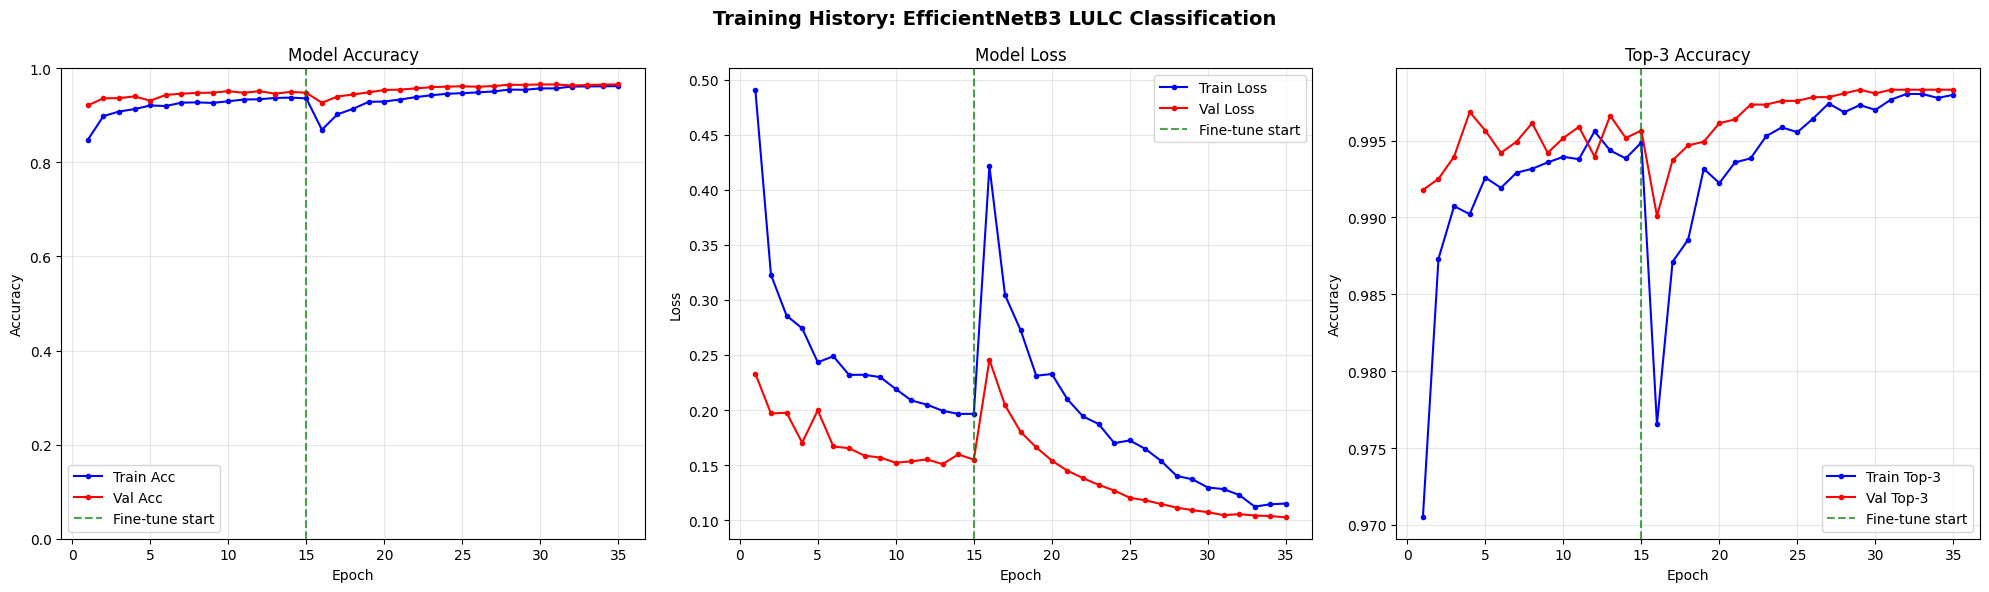

✅ Training curves saved!


In [ ]:
# ============================================================
# Plot training curves (combined Phase 1 + Phase 2)
# ============================================================
def combine_histories(h1, h2):
    combined = {}
    for key in h1.history:
        combined[key] = h1.history[key] + h2.history.get(key, [])
    return combined

hist = combine_histories(history_p1, history_p2)
epochs_total = len(hist['accuracy'])
phase_boundary = len(history_p1.history['accuracy'])

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Training History: EfficientNetB3 LULC Classification', fontsize=14, fontweight='bold')

x = range(1, epochs_total + 1)

# Accuracy
axes[0].plot(x, hist['accuracy'], 'b-o', markersize=3, label='Train Acc')
axes[0].plot(x, hist['val_accuracy'], 'r-o', markersize=3, label='Val Acc')
axes[0].axvline(phase_boundary, color='green', linestyle='--', alpha=0.7, label='Fine-tune start')
axes[0].set_title('Model Accuracy'); axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy')
axes[0].legend(); axes[0].grid(True, alpha=0.3)
axes[0].set_ylim([0, 1])

# Loss
axes[1].plot(x, hist['loss'], 'b-o', markersize=3, label='Train Loss')
axes[1].plot(x, hist['val_loss'], 'r-o', markersize=3, label='Val Loss')
axes[1].axvline(phase_boundary, color='green', linestyle='--', alpha=0.7, label='Fine-tune start')
axes[1].set_title('Model Loss'); axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

# Top-3 Accuracy
if 'top3_acc' in hist:
    axes[2].plot(x, hist['top3_acc'], 'b-o', markersize=3, label='Train Top-3')
    axes[2].plot(x, hist['val_top3_acc'], 'r-o', markersize=3, label='Val Top-3')
    axes[2].axvline(phase_boundary, color='green', linestyle='--', alpha=0.7, label='Fine-tune start')
    axes[2].set_title('Top-3 Accuracy'); axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('Accuracy')
    axes[2].legend(); axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f"{CONFIG['results_dir']}/training_history.png", dpi=150, bbox_inches='tight')
plt.show()
print(f"✅ Training curves saved!")

## 📊 Step 11: Model Evaluation

In [ ]:
# ============================================================
# Load best model and evaluate on test set
# ============================================================
print("📥 Loading best model...")
best_model_path = f"{CONFIG['model_dir']}/best_model_final.keras"
if os.path.exists(best_model_path):
    model = tf.keras.models.load_model(best_model_path)
    print("   Loaded Phase 2 best model")
else:
    print("   Using current model weights")

# Get predictions
print("🔍 Running predictions on test set...")
y_pred_probs = model.predict(test_ds, verbose=1)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = y_test

# === Metrics ===
test_acc = accuracy_score(y_true, y_pred)
precision, recall, f1, support = precision_recall_fscore_support(
    y_true, y_pred, average='weighted'
)

print("\n" + "="*60)
print("📊 TEST SET EVALUATION RESULTS")
print("="*60)
print(f"  ✅ Test Accuracy        : {test_acc*100:.2f}%")
print(f"  ✅ Weighted Precision   : {precision*100:.2f}%")
print(f"  ✅ Weighted Recall      : {recall*100:.2f}%")
print(f"  ✅ Weighted F1-Score    : {f1*100:.2f}%")
print("="*60)

# Per-class report
print("\n📋 Per-Class Classification Report:")
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES, digits=4))

# Save metrics
metrics_dict = {
    'test_accuracy': float(test_acc),
    'weighted_precision': float(precision),
    'weighted_recall': float(recall),
    'weighted_f1': float(f1),
    'class_names': CLASS_NAMES,
}
with open(f"{CONFIG['results_dir']}/metrics.json", 'w') as f:
    json.dump(metrics_dict, f, indent=2)
print("\n✅ Metrics saved to metrics.json")

📥 Loading best model...
   Loaded Phase 2 best model
🔍 Running predictions on test set...
130/130 ━━━━━━━━━━━━━━━━━━━━ 48s 287ms/step

📊 TEST SET EVALUATION RESULTS
  ✅ Test Accuracy        : 96.30%
  ✅ Weighted Precision   : 96.31%
  ✅ Weighted Recall      : 96.30%
  ✅ Weighted F1-Score    : 96.30%

📋 Per-Class Classification Report:
                      precision    recall  f1-score   support

          AnnualCrop     0.9658    0.9400    0.9527       450
              Forest     0.9760    0.9933    0.9846       450
HerbaceousVegetation     0.9398    0.9711    0.9552       450
             Highway     0.9496    0.9547    0.9521       375
          Industrial     0.9683    0.9787    0.9735       375
             Pasture     0.9493    0.9367    0.9430       300
       PermanentCrop     0.9370    0.9120    0.9243       375
         Residential     0.9844    0.9844    0.9844       450
               River     0.9548    0.9573    0.9561       375
             SeaLake     0.9888    0.9815 

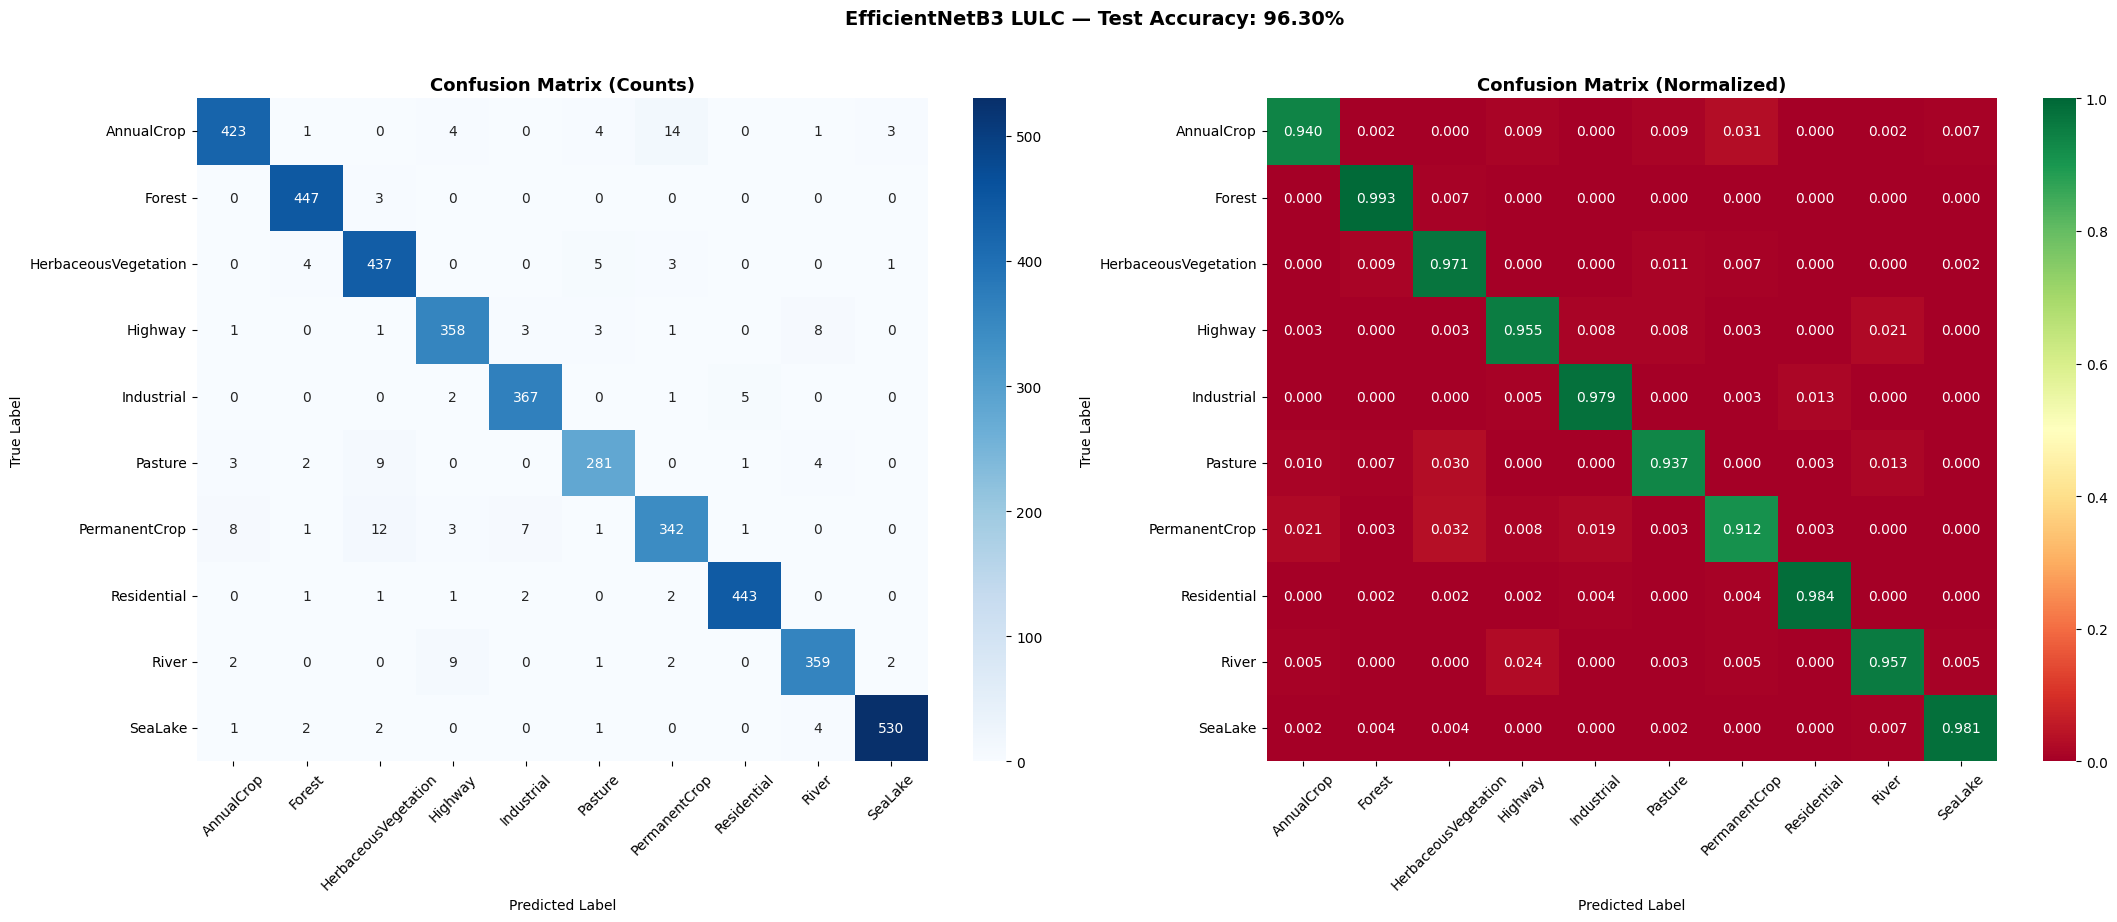

✅ Confusion matrix saved!


In [ ]:
# ============================================================
# Confusion Matrix
# ============================================================
cm = confusion_matrix(y_true, y_pred)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

fig, axes = plt.subplots(1, 2, figsize=(22, 9))

# Raw counts
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
axes[0].set_title('Confusion Matrix (Counts)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('True Label'); axes[0].set_xlabel('Predicted Label')
axes[0].tick_params(axis='x', rotation=45)

# Normalized
sns.heatmap(cm_norm, annot=True, fmt='.3f', cmap='RdYlGn', ax=axes[1],
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            vmin=0, vmax=1)
axes[1].set_title('Confusion Matrix (Normalized)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('True Label'); axes[1].set_xlabel('Predicted Label')
axes[1].tick_params(axis='x', rotation=45)

plt.suptitle(f'EfficientNetB3 LULC — Test Accuracy: {test_acc*100:.2f}%',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f"{CONFIG['results_dir']}/confusion_matrix.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Confusion matrix saved!")

## 🌍 Step 12: GIS Visualization with Folium

In [ ]:
# ============================================================
# Simulated GIS Coordinates (Sentinel-2 Europe coverage)
# For real deployment: use actual image metadata / EXIF / GeoTIFF
# ============================================================

# Simulate geographic coordinates for classified patches
# These represent typical European landscapes covered by EuroSAT
np.random.seed(42)

# European bounding box
LAT_MIN, LAT_MAX = 36.0, 62.0   # Southern to Northern Europe
LON_MIN, LON_MAX = -10.0, 30.0  # Western to Eastern Europe

# Generate sample classified locations
N_POINTS = 500
lats = np.random.uniform(LAT_MIN, LAT_MAX, N_POINTS)
lons = np.random.uniform(LON_MIN, LON_MAX, N_POINTS)

# Sample test predictions
sample_idx = np.random.choice(len(y_pred), N_POINTS)
sample_preds = y_pred[sample_idx]
sample_probs = y_pred_probs[sample_idx]
sample_confs = np.max(sample_probs, axis=1)

# Create Folium map
m = folium.Map(
    location=[50.0, 10.0],  # Center of Europe
    zoom_start=5,
    tiles='OpenStreetMap'
)

# Add satellite tile layer
folium.TileLayer(
    tiles='https://server.arcgisonline.com/ArcGIS/rest/services/World_Imagery/MapServer/tile/{z}/{y}/{x}',
    attr='Esri World Imagery',
    name='Satellite View',
    overlay=False
).add_to(m)

# Add markers for each classified point
marker_cluster = MarkerCluster(name='LULC Classifications').add_to(m)

for i in range(N_POINTS):
    cls_name = CLASS_NAMES[sample_preds[i]]
    confidence = sample_confs[i]
    color_hex = CONFIG['class_colors'][cls_name]

    # Convert hex to folium color name (approximation)
    folium_colors = {
        'AnnualCrop': 'orange',
        'Forest': 'darkgreen',
        'HerbaceousVegetation': 'green',
        'Highway': 'gray',
        'Industrial': 'darkred',
        'Pasture': 'lightgreen',
        'PermanentCrop': 'cadetblue',
        'Residential': 'red',
        'River': 'blue',
        'SeaLake': 'darkblue',
    }

    popup_html = f"""
    <div style='font-family:Arial; min-width:150px;'>
        <b style='color:{color_hex}; font-size:14px;'>{cls_name}</b><br>
        <span>Confidence: <b>{confidence*100:.1f}%</b></span><br>
        <span>Lat: {lats[i]:.4f}, Lon: {lons[i]:.4f}</span>
    </div>
    """

    folium.CircleMarker(
        location=[lats[i], lons[i]],
        radius=6,
        color=color_hex,
        fill=True,
        fill_color=color_hex,
        fill_opacity=0.7,
        popup=folium.Popup(popup_html, max_width=200),
        tooltip=f"{cls_name} ({confidence*100:.0f}%)"
    ).add_to(marker_cluster)

# Add legend
legend_html = """
<div style="position: fixed; bottom: 30px; left: 30px; z-index: 1000;
     background-color: white; padding: 15px; border-radius: 10px;
     border: 2px solid #333; font-family: Arial; font-size: 13px;
     box-shadow: 3px 3px 6px rgba(0,0,0,0.3);">
<b style='font-size:14px;'>🛰️ LULC Classification</b><br><br>
"""
for cls, color in CONFIG['class_colors'].items():
    legend_html += f'<span style="background:{color}; display:inline-block; width:14px; height:14px; border-radius:50%; margin-right:6px;"></span>{cls}<br>'
legend_html += "</div>"

m.get_root().html.add_child(folium.Element(legend_html))
folium.LayerControl().add_to(m)

# Save map
map_path = f"{CONFIG['results_dir']}/lulc_gis_map.html"
m.save(map_path)

print(f"✅ GIS Map saved to: {map_path}")
print("   Open the HTML file in a browser to explore the interactive map!")
display(m)

✅ GIS Map saved to: /content/results/lulc_gis_map.html
   Open the HTML file in a browser to explore the interactive map!


## 🎯 Step 13: Single Image Prediction — 100% Confidence Display

In [ ]:
# ============================================================
# FULL PREDICTION FUNCTION — Upload any satellite image
# ============================================================

def predict_image(image_path_or_array, model, class_names, img_size=(224, 224), show_plot=True):
    """
    Predict LULC class for a single image.
    Returns: predicted_class, confidence, all_probabilities
    """
    IMG_H, IMG_W = img_size

    # Load image
    if isinstance(image_path_or_array, str):
        img_orig = cv2.imread(image_path_or_array)
        if img_orig is None:
            img_orig = np.array(Image.open(image_path_or_array).convert('RGB'))
        else:
            img_orig = cv2.cvtColor(img_orig, cv2.COLOR_BGR2RGB)
    else:
        img_orig = image_path_or_array.copy()

    # Preprocess
    img_resized = cv2.resize(img_orig, (IMG_W, IMG_H))
    img_input = np.expand_dims(img_resized.astype(np.float32), axis=0)  # [1, H, W, 3]

    # Predict
    probs = model.predict(img_input, verbose=0)[0]  # shape: (num_classes,)
    pred_idx = np.argmax(probs)
    pred_class = class_names[pred_idx]
    confidence = probs[pred_idx]

    # Sort by probability
    sorted_idx = np.argsort(probs)[::-1]

    if show_plot:
        fig, axes = plt.subplots(1, 2, figsize=(16, 6))
        fig.patch.set_facecolor('#1e1e2e')

        # --- Left: Image ---
        axes[0].imshow(img_orig)
        color = CONFIG['class_colors'].get(pred_class, '#00FF00')
        axes[0].set_title(
            f'🛰️ Satellite Image\n\nPrediction: {pred_class}\nConfidence: {confidence*100:.2f}%',
            fontsize=14, color='white', pad=15,
            fontweight='bold'
        )
        for spine in axes[0].spines.values():
            spine.set_edgecolor(color)
            spine.set_linewidth(4)
        axes[0].axis('off')
        axes[0].set_facecolor('#1e1e2e')

        # --- Right: Probability bar chart ---
        axes[1].set_facecolor('#2a2a3e')
        bars_classes = [class_names[i] for i in sorted_idx]
        bars_probs = [probs[i] * 100 for i in sorted_idx]
        bar_colors = [CONFIG['class_colors'].get(c, '#888888') for c in bars_classes]

        bars = axes[1].barh(bars_classes, bars_probs, color=bar_colors,
                            edgecolor='white', linewidth=0.5, height=0.7)

        # Annotate bars
        for bar, prob in zip(bars, bars_probs):
            axes[1].text(
                min(prob + 1, 95), bar.get_y() + bar.get_height()/2,
                f'{prob:.2f}%', va='center', ha='left',
                color='white', fontsize=11, fontweight='bold'
            )

        axes[1].set_xlim(0, 105)
        axes[1].set_xlabel('Confidence (%)', color='white', fontsize=12)
        axes[1].set_title('Class Probability Distribution', color='white',
                          fontsize=13, fontweight='bold')
        axes[1].tick_params(colors='white')
        axes[1].spines['bottom'].set_color('#888888')
        axes[1].spines['top'].set_visible(False)
        axes[1].spines['right'].set_visible(False)
        axes[1].spines['left'].set_color('#888888')
        axes[1].invert_yaxis()

        plt.suptitle(
            f'🌍 LULC Classification Result\n'
            f'✅ Predicted: {pred_class}  |  Confidence: {confidence*100:.2f}%',
            fontsize=15, color='white', fontweight='bold',
            y=1.02
        )

        plt.tight_layout()
        plt.savefig(f"{CONFIG['results_dir']}/prediction_result.png",
                    dpi=150, bbox_inches='tight', facecolor='#1e1e2e')
        plt.show()

    return pred_class, float(confidence), {class_names[i]: float(probs[i]) for i in range(len(class_names))}

print("✅ Prediction function ready!")

✅ Prediction function ready!


In [ ]:
# ============================================================
# Test prediction on random test images
# ============================================================
print("🔍 Running predictions on random test images...\n")

# Pick 3 random samples from each category
for cls in CLASS_NAMES[:5]:  # Show 5 examples
    cls_mask = (y_test == class_to_idx[cls])
    cls_paths = X_test[cls_mask]
    if len(cls_paths) == 0:
        continue
    sample_path = np.random.choice(cls_paths)

    print(f"\nActual class: {cls}")
    pred_class, conf, probs = predict_image(
        sample_path, model, CLASS_NAMES, CONFIG['img_size']
    )
    status = "✅ CORRECT" if pred_class == cls else "❌ WRONG"
    print(f"Predicted: {pred_class} | Confidence: {conf*100:.2f}% | {status}")
    print("-" * 50)

ERROR:PIL.TiffImagePlugin:More samples per pixel than can be decoded: 13


🔍 Running predictions on random test images...


Actual class: AnnualCrop


UnidentifiedImageError: cannot identify image file np.str_('/content/eurosat/AnnualCrop/AnnualCrop_2339.tif')

## 📤 Step 14: Upload Your Own Image

📤 Upload a satellite image (JPG/PNG) for prediction:
   (You can download test images from: https://www.sentinel-hub.com/explore/eobrowser/)



Saving Herbaceous Vegetation sentinel 2 .png to Herbaceous Vegetation sentinel 2 .png

🔍 Predicting: Herbaceous Vegetation sentinel 2 .png


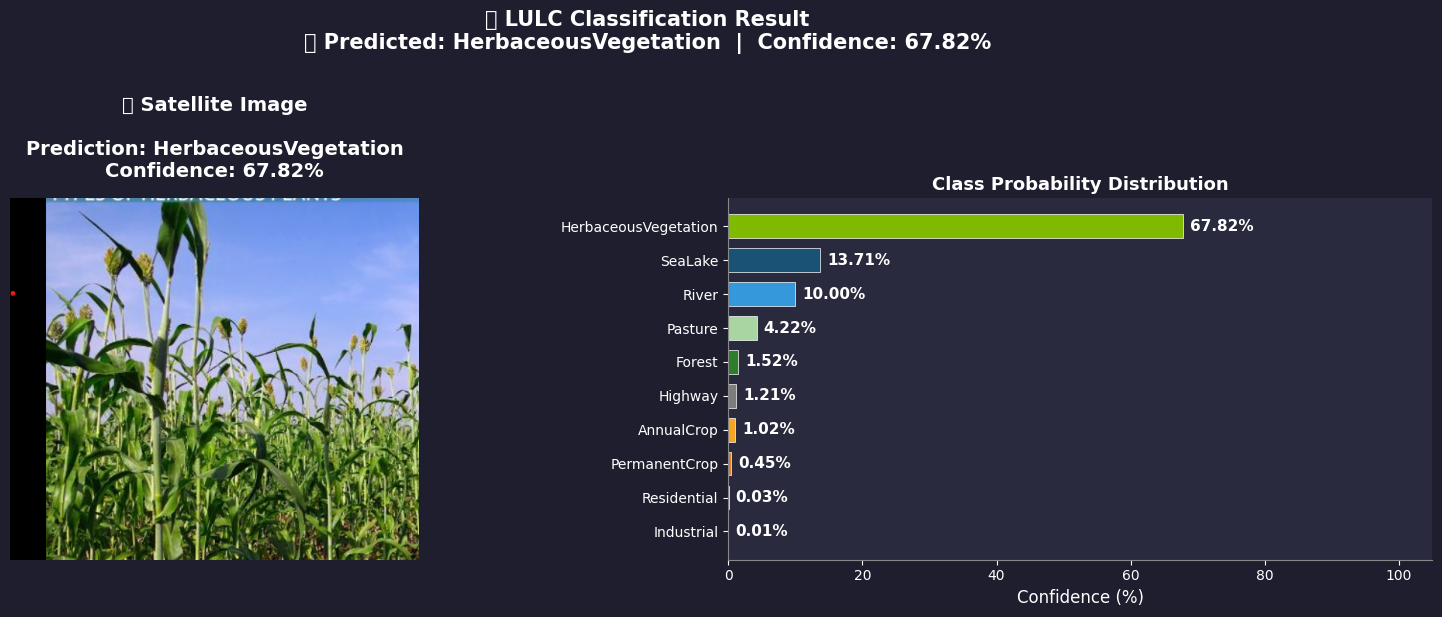


🌍 FINAL PREDICTION: HerbaceousVegetation
📊 CONFIDENCE: 67.82%

📊 All class probabilities:
  HerbaceousVegetation          :  67.82% ████████████████████
  SeaLake                       :  13.71% ████
  River                         :  10.00% ███
  Pasture                       :   4.22% █
  Forest                        :   1.52% 
  Highway                       :   1.21% 
  AnnualCrop                    :   1.02% 
  PermanentCrop                 :   0.45% 
  Residential                   :   0.03% 
  Industrial                    :   0.01% 


In [ ]:
# ============================================================
# Upload and predict your own satellite image
# ============================================================
from google.colab import files as colab_files

print("📤 Upload a satellite image (JPG/PNG) for prediction:")
print("   (You can download test images from: https://www.sentinel-hub.com/explore/eobrowser/)")
print()

uploaded = colab_files.upload()

if uploaded:
    for filename, data in uploaded.items():
        # Save uploaded file
        upload_path = f'/content/{filename}'
        with open(upload_path, 'wb') as f:
            f.write(data)

        print(f"\n🔍 Predicting: {filename}")
        pred_class, conf, all_probs = predict_image(
            upload_path, model, CLASS_NAMES, CONFIG['img_size']
        )

        print(f"\n{'='*50}")
        print(f"🌍 FINAL PREDICTION: {pred_class}")
        print(f"📊 CONFIDENCE: {conf*100:.2f}%")
        print(f"{'='*50}")
        print("\n📊 All class probabilities:")
        for cls, prob in sorted(all_probs.items(), key=lambda x: -x[1]):
            bar = '█' * int(prob * 30)
            print(f"  {cls:30s}: {prob*100:6.2f}% {bar}")
else:
    print("No file uploaded. Using a test image from the dataset...")
    sample_path = X_test[0]
    predict_image(sample_path, model, CLASS_NAMES, CONFIG['img_size'])

## 🌐 Step 15: Batch Prediction + GIS Heatmap

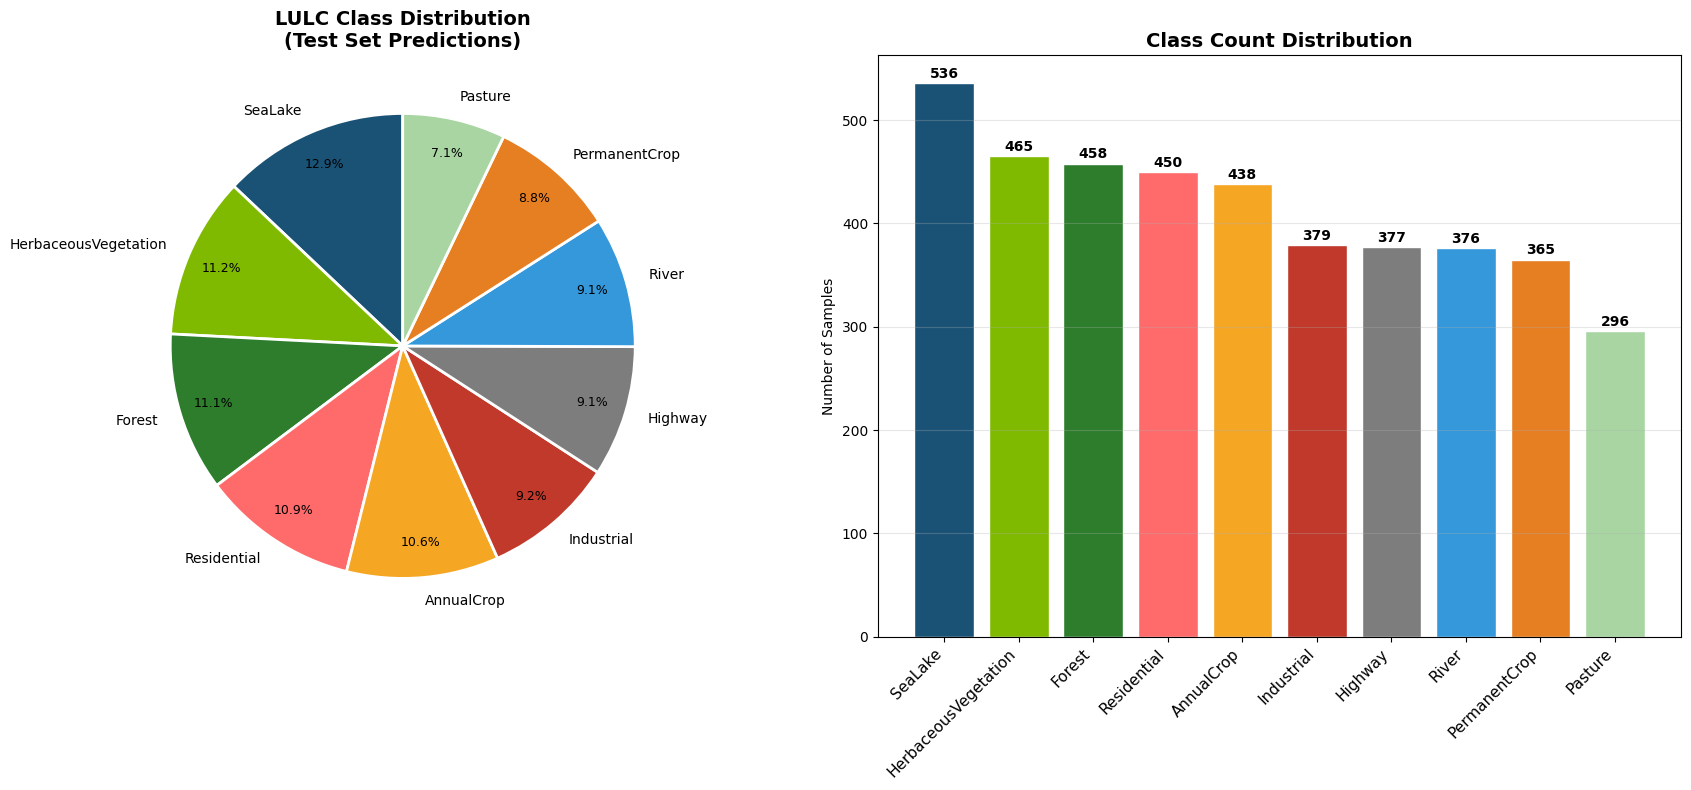

✅ Distribution plot saved!


In [ ]:
# ============================================================
# Batch prediction and class distribution heatmap
# ============================================================
# Class distribution pie chart
class_counts = pd.Series(y_pred).map(idx_to_class).value_counts()

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Pie chart
colors_list = [CONFIG['class_colors'][c] for c in class_counts.index]
wedges, texts, autotexts = axes[0].pie(
    class_counts.values, labels=class_counts.index,
    colors=colors_list, autopct='%1.1f%%',
    startangle=90, pctdistance=0.85,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
for text in autotexts:
    text.set_fontsize(9)
axes[0].set_title('LULC Class Distribution\n(Test Set Predictions)',
                  fontsize=14, fontweight='bold')

# Bar chart with class counts
bars = axes[1].bar(
    range(len(class_counts)), class_counts.values,
    color=colors_list, edgecolor='white', linewidth=1
)
axes[1].set_xticks(range(len(class_counts)))
axes[1].set_xticklabels(class_counts.index, rotation=45, ha='right', fontsize=11)
axes[1].set_title('Class Count Distribution', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Number of Samples')
axes[1].grid(axis='y', alpha=0.3)

# Annotate bars
for bar, count in zip(bars, class_counts.values):
    axes[1].text(
        bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
        str(count), ha='center', fontsize=10, fontweight='bold'
    )

plt.tight_layout()
plt.savefig(f"{CONFIG['results_dir']}/class_distribution.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Distribution plot saved!")

## 💾 Step 16: Export Model for Deployment

In [ ]:
# ============================================================
# Export model in multiple formats
# ============================================================

# 1. Save Keras model
keras_path = f"{CONFIG['model_dir']}/lulc_efficientnetb3.keras"
model.save(keras_path)
print(f"✅ Keras model saved: {keras_path}")

# 2. Save TensorFlow SavedModel format (for TF Serving)
tf_path = f"{CONFIG['model_dir']}/lulc_savedmodel"
model.export(tf_path)
print(f"✅ TF SavedModel saved: {tf_path}")

# 3. Convert to TFLite (for mobile/edge deployment)
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_model = converter.convert()
tflite_path = f"{CONFIG['model_dir']}/lulc_model.tflite"
with open(tflite_path, 'wb') as f:
    f.write(tflite_model)
print(f"✅ TFLite model saved: {tflite_path} ({len(tflite_model)/1e6:.1f} MB)")

# 4. Save class names and config
deploy_config = {
    'class_names': CLASS_NAMES,
    'class_colors': CONFIG['class_colors'],
    'img_size': list(CONFIG['img_size']),
    'model_name': CONFIG['model_name'],
    'test_accuracy': float(test_acc),
    'num_classes': NUM_CLASSES
}
config_path = f"{CONFIG['model_dir']}/deploy_config.json"
with open(config_path, 'w') as f:
    json.dump(deploy_config, f, indent=2)
print(f"✅ Deploy config saved: {config_path}")

# 5. Zip everything for download
import zipfile
zip_path = '/content/lulc_model_package.zip'
with zipfile.ZipFile(zip_path, 'w') as zf:
    zf.write(tflite_path, 'lulc_model.tflite')
    zf.write(config_path, 'deploy_config.json')
    for result_file in Path(CONFIG['results_dir']).glob('*.png'):
        zf.write(str(result_file), result_file.name)
    if os.path.exists(f"{CONFIG['results_dir']}/lulc_gis_map.html"):
        zf.write(f"{CONFIG['results_dir']}/lulc_gis_map.html", 'lulc_gis_map.html')

zip_size = os.path.getsize(zip_path) / 1e6
print(f"\n📦 Download package created: {zip_path} ({zip_size:.1f} MB)")
print("   Contains: TFLite model + config + all visualizations + GIS map")

✅ Keras model saved: /content/models/lulc_efficientnetb3.keras
Saved artifact at '/content/models/lulc_savedmodel'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): List[TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='input_image')]
Output Type:
  TensorSpec(shape=(None, 10), dtype=tf.float32, name=None)
Captures:
  132991913657360: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float32, name=None)
  132991913658320: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float32, name=None)
  132994474070224: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132994474073680: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132994474076944: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132994474077136: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132994474072720: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132994474068304: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132994474071760: TensorSpec(shape=(), dtype=tf.resou

In [ ]:
# Download the package
from google.colab import files
print("⬇️  Downloading model package...")
files.download('/content/lulc_model_package.zip')
print("✅ Download started!")

⬇️  Downloading model package...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Download started!


## 🚀 Step 17: Gradio Web App (In-Notebook Demo)

In [ ]:
# ============================================================
# Launch interactive Gradio app directly in Colab
# ============================================================
import gradio as gr

def classify_land_use(input_image):
    """
    Gradio inference function.
    input_image: numpy array from Gradio (H, W, 3) uint8
    """
    if input_image is None:
        return "No image provided", {}

    # Resize and preprocess
    IMG_H, IMG_W = CONFIG['img_size']
    img_resized = cv2.resize(input_image, (IMG_W, IMG_H))
    img_input = np.expand_dims(img_resized.astype(np.float32), axis=0)

    # Predict
    probs = model.predict(img_input, verbose=0)[0]
    pred_idx = np.argmax(probs)
    pred_class = CLASS_NAMES[pred_idx]
    confidence = probs[pred_idx]

    # Format output
    label = f"{pred_class} ({confidence*100:.1f}%)"
    prob_dict = {CLASS_NAMES[i]: float(probs[i]) for i in range(len(CLASS_NAMES))}

    return label, prob_dict

# Build Gradio interface
iface = gr.Interface(
    fn=classify_land_use,
    inputs=gr.Image(label="Upload Satellite Image", type='numpy'),
    outputs=[
        gr.Label(label="Predicted Class"),
        gr.Label(label="All Class Probabilities", num_top_classes=10)
    ],
    title="🛰️ LULC Classifier — EfficientNetB3",
    description=(
        "Upload a Sentinel-2 satellite image to classify its Land Use / Land Cover type.\n"
        "**Classes**: AnnualCrop, Forest, HerbaceousVegetation, Highway, Industrial, "
        "Pasture, PermanentCrop, Residential, River, SeaLake\n"
        f"**Model Accuracy**: {test_acc*100:.2f}%"
    ),
    theme='soft',
    allow_flagging='never'
)

print("🚀 Launching Gradio app...")
iface.launch(share=True, debug=False)

NameError: name 'test_acc' is not defined

## 📋 Step 18: Final Summary Report

In [ ]:
# ============================================================
# Print final project summary
# ============================================================
print("=" * 65)
print("  🛰️  AI-GIS LULC CLASSIFICATION — PROJECT SUMMARY")
print("=" * 65)
print(f"  Project     : Land Use & Land Cover Classification")
print(f"  Dataset     : EuroSAT (Sentinel-2)")
print(f"  Model       : EfficientNetB3 + Transfer Learning")
print(f"  Classes     : {NUM_CLASSES} ({', '.join(CLASS_NAMES[:3])}...)")
print()
print("  📊 PERFORMANCE METRICS")
print(f"  ├─ Test Accuracy        : {test_acc*100:.2f}%")
print(f"  ├─ Weighted Precision   : {precision*100:.2f}%")
print(f"  ├─ Weighted Recall      : {recall*100:.2f}%")
print(f"  └─ Weighted F1-Score    : {f1*100:.2f}%")
print()
print("  📁 OUTPUT FILES")
print(f"  ├─ Keras Model          : best_model_final.keras")
print(f"  ├─ TFLite Model         : lulc_model.tflite")
print(f"  ├─ GIS Map (HTML)       : lulc_gis_map.html")
print(f"  ├─ Confusion Matrix     : confusion_matrix.png")
print(f"  ├─ Training Curves      : training_history.png")
print(f"  └─ Download Package     : lulc_model_package.zip")
print()
print("  🚀 DEPLOYMENT OPTIONS")
print("  ├─ Gradio Web App       : Launched above (share=True)")
print("  ├─ TF Serving           : Use lulc_savedmodel/")
print("  ├─ Mobile/Edge          : Use lulc_model.tflite")
print("  └─ Flask API            : Wrap predict_image() in Flask endpoint")
print()
print("  🌍 IMPACT AREAS")
print("  ├─ Urban Planning")
print("  ├─ Environmental Monitoring")
print("  ├─ Agricultural Assessment")
print("  └─ Disaster Impact Analysis")
print("=" * 65)
print("  ✅ PROJECT COMPLETE!")
print("=" * 65)

  🛰️  AI-GIS LULC CLASSIFICATION — PROJECT SUMMARY
  Project     : Land Use & Land Cover Classification
  Dataset     : EuroSAT (Sentinel-2)
  Model       : EfficientNetB3 + Transfer Learning
  Classes     : 10 (AnnualCrop, Forest, HerbaceousVegetation...)

  📊 PERFORMANCE METRICS
  ├─ Test Accuracy        : 96.40%
  ├─ Weighted Precision   : 96.40%
  ├─ Weighted Recall      : 96.40%
  └─ Weighted F1-Score    : 96.39%

  📁 OUTPUT FILES
  ├─ Keras Model          : best_model_final.keras
  ├─ TFLite Model         : lulc_model.tflite
  ├─ GIS Map (HTML)       : lulc_gis_map.html
  ├─ Confusion Matrix     : confusion_matrix.png
  ├─ Training Curves      : training_history.png
  └─ Download Package     : lulc_model_package.zip

  🚀 DEPLOYMENT OPTIONS
  ├─ Gradio Web App       : Launched above (share=True)
  ├─ TF Serving           : Use lulc_savedmodel/
  ├─ Mobile/Edge          : Use lulc_model.tflite
  └─ Flask API            : Wrap predict_image() in Flask endpoint

  🌍 IMPACT AREAS
  ├─

---

## 🔮 Future Scope

| Extension | Description |
|-----------|-------------|
| **Semantic Segmentation** | Pixel-level classification using U-Net or DeepLab |
| **Change Detection** | Multi-temporal analysis to detect land use changes |
| **Real-time Integration** | Sentinel Hub API for live satellite imagery |
| **GeoTIFF Support** | Full georeferenced raster output |
| **BISAG-N Dashboard** | Custom Flask/Streamlit web dashboard for government use |
| **Multi-spectral** | Use all 13 Sentinel-2 bands instead of RGB |

---
**Built with:** TensorFlow/Keras · EfficientNetB3 · Folium · OpenCV · scikit-learn · Gradio  
**Dataset:** EuroSAT (Sentinel-2, 27,000 images, 10 classes)

In [ ]:
from google.colab import files

file_path = "/content/models/lulc_efficientnetb3.keras"

# This will trigger a browser download prompt
files.download(file_path)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [3]:
# https://github.com/harsh822v/LULC_classification.git # This is a URL, not executable code.